
# Problem Statement.


##### Develop a Machine Learning model that predicts the selling price of vehicles using historical vehicle sales transaction data. model should analyze various factors such as vehicle specifications, condition, mileage, market value, and transaction details to estimate the expected selling price accurately.



# Objective:
### The primary objective of this project is to:

* Build a predictive model capable of estimating vehicle selling prices.
* Identify the most influential factors affecting vehicle prices.
* Improve pricing strategies for dealerships and automotive businesses.
* Support market trend analysis and decision-making.

# Business Requirement.

##### Automotive dealerships, vehicle auction platforms, banks, and insurance companies face challenges in determining accurate resale prices for vehicles due to changing market trends, vehicle conditions, mileage variations, and customer demand.

# Current manual valuation methods are:

* Time-consuming
* Inconsistent
* Error-prone
* Dependent on human expertise
##### The organization requires an intelligent machine learning solution capable of predicting vehicle selling prices accurately using historical transaction and vehicle data.

# The proposed ML solution should:

* Predict vehicle selling prices with high accuracy.
* Reduce pricing errors.
* Assist in inventory valuation.
* Enable data-driven business decisions.

# In Every (ML AND EDA) projects first we need to fallow this steps.



* Understand Problem
    ↓
* Clean Data
    ↓
* Handle Null Values
    ↓
* Handle Outliers
    ↓
* Encoding
    ↓
* Scaling
    ↓
* Train-Test Split
    ↓
* Choose Algorithm
    ↓
* Train Model
    ↓
* Predict
    ↓
* Evaluate
    ↓
* Check Overfitting
    ↓
* Improve Model


 # **. Import libraries**
 

In [1]:
!pip install feature-engine

In [2]:
import numpy as np                                     # linear algebra
import pandas as pd                                    # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns                                  # statistical data visualization      
import matplotlib.pyplot as plt                        # data visualization
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# **. Import dataset**

In [3]:
df=pd.read_csv(r"C:\Users\thadi\OneDrive\Attachments\Desktop\ML_Projects\car_prices1.csv")

# **. Exploratory data analysis** 




Now, I will explore the data to gain insights about the data. 

In [4]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
print(df.shape)

(558837, 16)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB
None


In [9]:
df.describe()                                 # Numerical columns

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [10]:
a = df.describe()
a.columns

Index(['year', 'condition', 'odometer', 'mmr', 'sellingprice'], dtype='object')

In [11]:
df.describe(include='object')                                

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,548536,548438,548186,545642,493485,558833,558837,558088,558088,558837,558825
unique,96,973,1963,87,4,550297,64,46,17,14263,3766
top,Ford,Altima,Base,Sedan,automatic,automatic,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,93554,19349,55817,199437,475915,22,82945,110970,244329,19693,5334


In [12]:
b = df.describe(include='object')
print(b.columns)

Index(['make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'color', 'interior', 'seller', 'saledate'],
      dtype='object')


In [14]:
print(df.columns)

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')


In [15]:
df.drop(['vin','saledate','state'],axis=1,inplace=True)

In [16]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'condition',
       'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice'],
      dtype='object')

## Finding Null Values.

In [17]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
dtype: int64

In [18]:
df.isnull().sum()/len(df)*100

year             0.000000
make             1.843292
model            1.860829
trim             1.905922
body             2.361154
transmission    11.694287
condition        2.115107
odometer         0.016821
color            0.134028
interior         0.134028
seller           0.000000
mmr              0.006800
sellingprice     0.002147
dtype: float64

## Fill Null Values.

In [19]:
df['make']=df['make'].fillna('Ford')
df['model']=df['model'].fillna('Altima')
df['trim']=df['trim'].fillna('Base')
df['body']=df['body'].fillna('Sedan')
df['transmission']=df['transmission'].fillna('automatic')
df['color']=df['color'].fillna('black')
df['interior']=df['interior'].fillna('black')
df['condition']=df['condition'].fillna(30.672365)
df['odometer']=df['odometer'].fillna(52266.0)
df['mmr']=df['mmr'].fillna(12250.0)
df['sellingprice']=df['sellingprice'].fillna(12100.0)

In [20]:
df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['condition'].median()

34.0

In [23]:
df['condition'].mean()

np.float64(30.67236484753157)

<Axes: xlabel='sellingprice', ylabel='Count'>

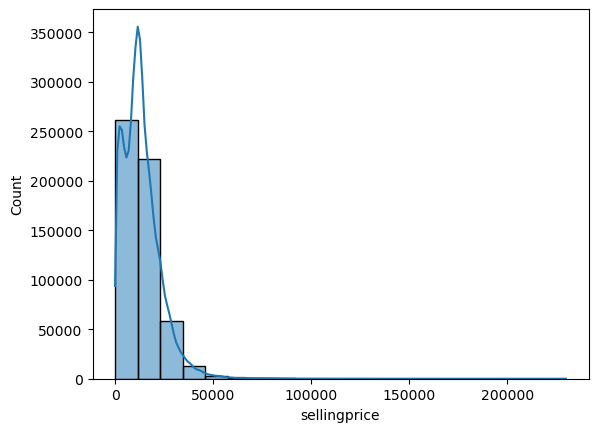

In [24]:
sns.histplot(x='sellingprice',data=df,kde=True,bins=20)

In [25]:
df['sellingprice'].skew()

np.float64(1.9534737517647272)

<Axes: xlabel='sellingprice'>

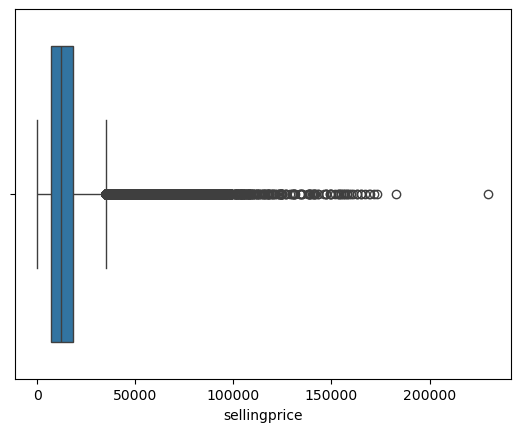

In [26]:
sns.boxplot(x='sellingprice',data=df)

<Axes: xlabel='mmr'>

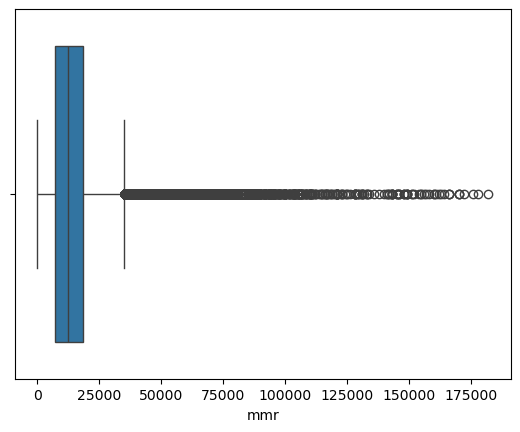

In [27]:
sns.boxplot(x='mmr',data=df)

<Axes: xlabel='odometer'>

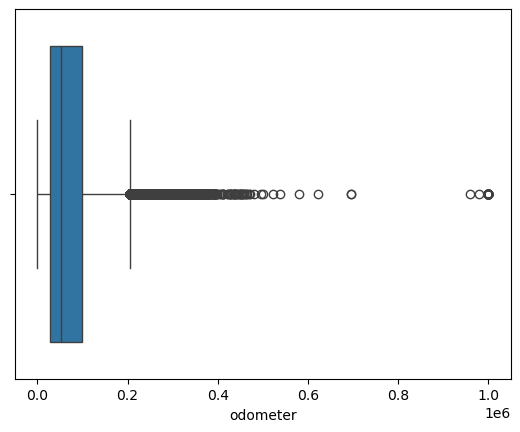

In [28]:
sns.boxplot(x='odometer',data=df)

<Axes: xlabel='condition'>

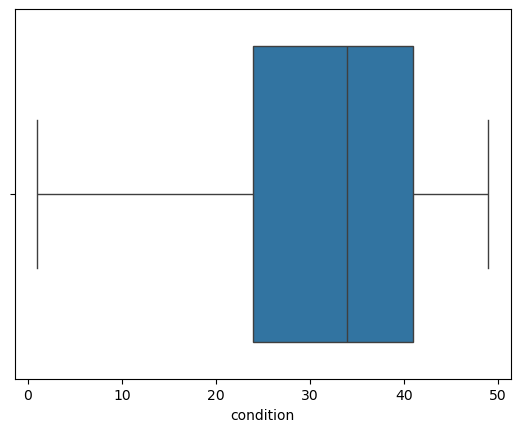

In [29]:
sns.boxplot(x='condition',data=df)

<Axes: xlabel='condition', ylabel='Count'>

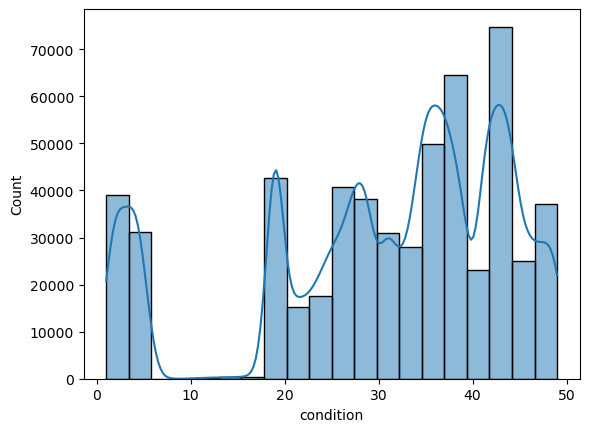

In [30]:
sns.histplot(x='condition',data=df,kde=True,bins=20)

In [31]:
df['condition'].skew()

np.float64(-0.8419073465475098)

In [32]:
winsor = Winsorizer(capping_method = 'quantiles', tail='both',variables=['mmr','odometer','sellingprice'])

In [33]:
winsor.fit(df)

Winsorizer(capping_method='quantiles', tail='both',
           variables=['mmr', 'odometer', 'sellingprice'])

In [34]:
cleared_data = winsor.transform(df)

<Axes: xlabel='sellingprice'>

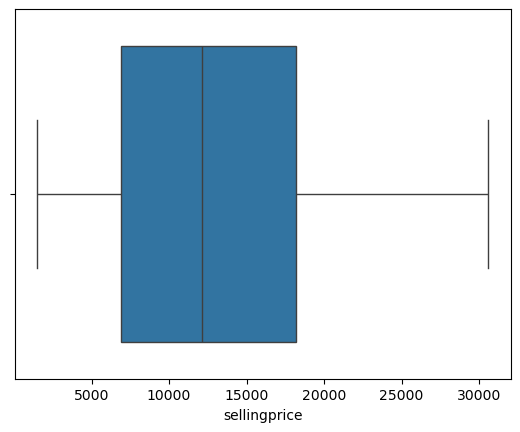

In [35]:
sns.boxplot(x='sellingprice',data=cleared_data)

<Axes: xlabel='sellingprice', ylabel='Count'>

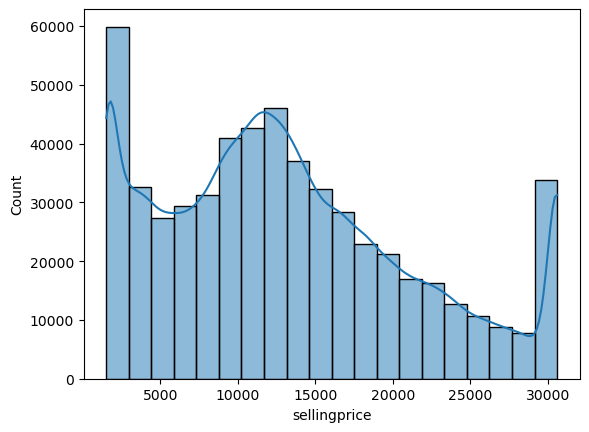

In [36]:
sns.histplot(x='sellingprice',data=cleared_data,kde=True,bins=20)

In [37]:
cleared_data.duplicated().sum()

np.int64(277)

In [38]:
cleared_data = cleared_data.drop_duplicates()

In [39]:
cleared_data.duplicated().sum()

np.int64(0)

In [40]:
cleared_data.head()

,year,make,model,trim,body,transmission,condition,odometer,color,interior,seller,mmr,sellingprice
0,2015,Kia,Sorento,LX,SUV,automatic,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0
1,2015,Kia,Sorento,LX,SUV,automatic,5.0,10513.0,white,beige,kia motors america inc,20800.0,21500.0
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,45.0,10513.0,gray,black,financial services remarketing (lease),30600.0,30000.0
3,2015,Volvo,S60,T5,Sedan,automatic,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,43.0,10513.0,gray,black,financial services remarketing (lease),30600.0,30600.0


## Encoding:
####        machine won't understand categarical data that's why we need to use ENCODING ....means change categarical to numerical.




In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
le = LabelEncoder()

In [45]:
cleared_data['make'] = le.fit_transform(cleared_data['make'])
cleared_data['model'] = le.fit_transform(cleared_data['model'])
cleared_data['trim'] = le.fit_transform(cleared_data['trim'])
cleared_data['body'] = le.fit_transform(cleared_data['body'])
cleared_data['transmission'] = le.fit_transform(cleared_data['transmission'])
cleared_data['color'] = le.fit_transform(cleared_data['color'])
cleared_data['interior'] = le.fit_transform(cleared_data['interior'])
cleared_data['seller'] = le.fit_transform(cleared_data['seller'])

In [46]:
cleared_data.head()

,year,make,model,trim,body,transmission,condition,odometer,color,interior,seller,mmr,sellingprice
0,2015,24,658,998,36,1,5.0,16639.0,43,1,7202,20500.0,21500.0
1,2015,24,658,998,36,1,5.0,10513.0,43,0,7202,20800.0,21500.0
2,2014,3,9,283,37,1,45.0,10513.0,33,1,4978,30600.0,30000.0
3,2015,51,596,1399,37,1,41.0,14282.0,43,1,13795,27500.0,27750.0
4,2014,3,42,498,37,1,43.0,10513.0,33,1,4978,30600.0,30600.0


In [47]:
X = cleared_data.drop(['sellingprice'], axis=1)

In [48]:
y = cleared_data['sellingprice']

# **. Split data into separate training and test set**



In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state= 23)

In [50]:
X_train.shape

(390992, 12)

In [51]:
y_train.shape

(390992,)

In [52]:
# Normalization
# scaler1 = StandardScaler() #(x-u)/sigma
# '''
# fit : Mean value, Standard_deviation(fit)
# transform : x-Mean/standard_deviation
# '''
# X_train = scaler1.fit_transform(X_train)
# X_test = scaler1.transform(X_test)

In [53]:

scaler1 = StandardScaler()

X_train = scaler1.fit_transform(X_train)
X_test = scaler1.transform(X_test)

In [54]:
X_train

array([[-1.27233715,  1.84114599, -1.19367278, ..., -0.94147979,
         0.03521545, -0.68694301],
       [-1.27233715, -1.01287057, -0.8202158 , ..., -0.70607778,
         0.11507489, -0.44912135],
       [-0.76744461, -0.19743727,  1.63002635, ...,  0.47093225,
         0.11507489, -0.88721389],
       ...,
       [ 0.24234046, -0.19743727,  1.3704282 , ...,  0.47093225,
        -0.32353774, -0.53361062],
       [ 0.99967927, -1.01287057, -0.72002003, ...,  0.47093225,
        -0.36703042,  2.16378776],
       [-0.01010581, -0.53720114, -0.5469546 , ..., -0.70607778,
         0.07502231, -0.03293343]])

In [55]:
X_test

array([[ 0.747233  , -1.28468167,  1.77576566, ..., -0.70607778,
        -1.39070562,  2.16378776],
       [-1.01989088, -1.28468167, -1.40317304, ...,  2.11874631,
         1.10066328, -0.69007225],
       [ 0.49478673, -0.26539004, -1.30297727, ...,  2.11874631,
        -1.66959937, -0.06422575],
       ...,
       [-1.01989088,  1.84114599, -1.19367278, ...,  0.47093225,
        -0.82628365, -0.88408466],
       [ 0.49478673,  1.84114599, -0.92041158, ..., -0.70607778,
         1.71152659,  0.2111467 ],
       [ 0.99967927, -0.80901224, -0.85209628, ...,  0.47093225,
        -0.24760984,  0.72434083]])

In [56]:
lin_reg = LinearRegression()

In [57]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [58]:
y_pred = lin_reg.predict(X_test)

In [59]:
y_pred

array([30266.16176215,  7418.89570866, 12177.15075758, ...,
        6255.60369356, 15037.57702022, 17767.8937627 ])

In [60]:
mean_squared_error(y_pred, y_test)

2189576.071848322

In [61]:
lin_reg.score(X_test, y_test)

0.9664720919740432

# Applying 5-Fold Cross Validation:

In [62]:


scores = cross_val_score(lin_reg, X_train, y_train, cv = 5, scoring='r2')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.96580961 0.96649434 0.96605267 0.96686876 0.9665395 ]


## compute Average cross-validation score

In [63]:


print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.9664


In [64]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1, 5, 10, 20]}
ridge = Ridge()

grid_search = GridSearchCV(estimator=ridge, param_grid=parameters, scoring='r2', cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best R2 score found: ", grid_search.best_score_)

Best parameters found:  {'alpha': 1}
Best R2 score found:  0.9663529744642216
